In [31]:
from pint.models import get_model_and_toas
from pint.fitter import GLSFitter
from pint.residuals import Residuals
from pint.logging import setup as setup_log
from matplotlib import pyplot as plt

setup_log(level="ERROR")

6

In [32]:
m, t = get_model_and_toas("sim3_new.par", "sim3_new.tim")

In [33]:
res = Residuals(t, m)

In [34]:
ftr = GLSFitter(t, m)

In [35]:
ftr.fit_toas(maxiter=5)

10094.114573756320876

Text(0, 0.5, 'Resids (s)')

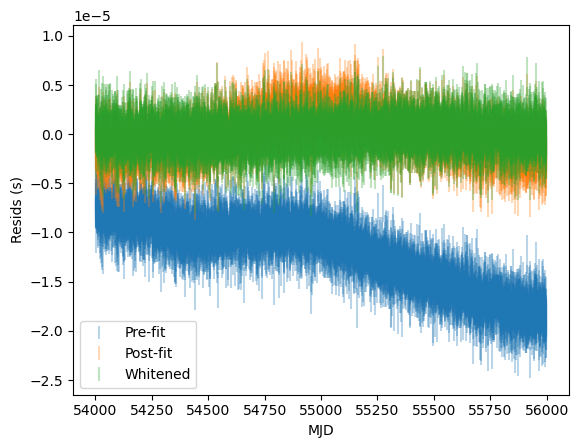

In [36]:
plt.errorbar(t.get_mjds(), res.calc_time_resids(), res.get_data_error(), ls="", label="Pre-fit", alpha=0.3)
plt.errorbar(t.get_mjds(), ftr.resids.calc_time_resids(), ftr.resids.get_data_error(), ls="", label="Post-fit", alpha=0.3)
plt.errorbar(t.get_mjds(), ftr.resids.calc_time_resids() - sum(ftr.resids.noise_resids.values()), ftr.resids.get_data_error(), ls="", label="Whitened", alpha=0.3)
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Resids (s)")

In [37]:
# Comparison between pre-fit and post-fit model
print(m.compare(ftr.model))

PARAMETER                          sim3_new.par                     sim3_new.par   Diff_Sigma1   Diff_Sigma2
--------------     ----------------------------   ------------------------------   -----------   -----------
PSR                                        SIM3                             SIM3                            
EPHEM                                     DE440                            DE440                            
CLOCK                              TT(BIPM2019)                     TT(BIPM2019)                            
UNITS                                       TDB                              TDB                            
DILATEFREQ                                False                            False                            
DMDATA                                    False                            False                            
NTOA                                          0                            10000                            
PX                 